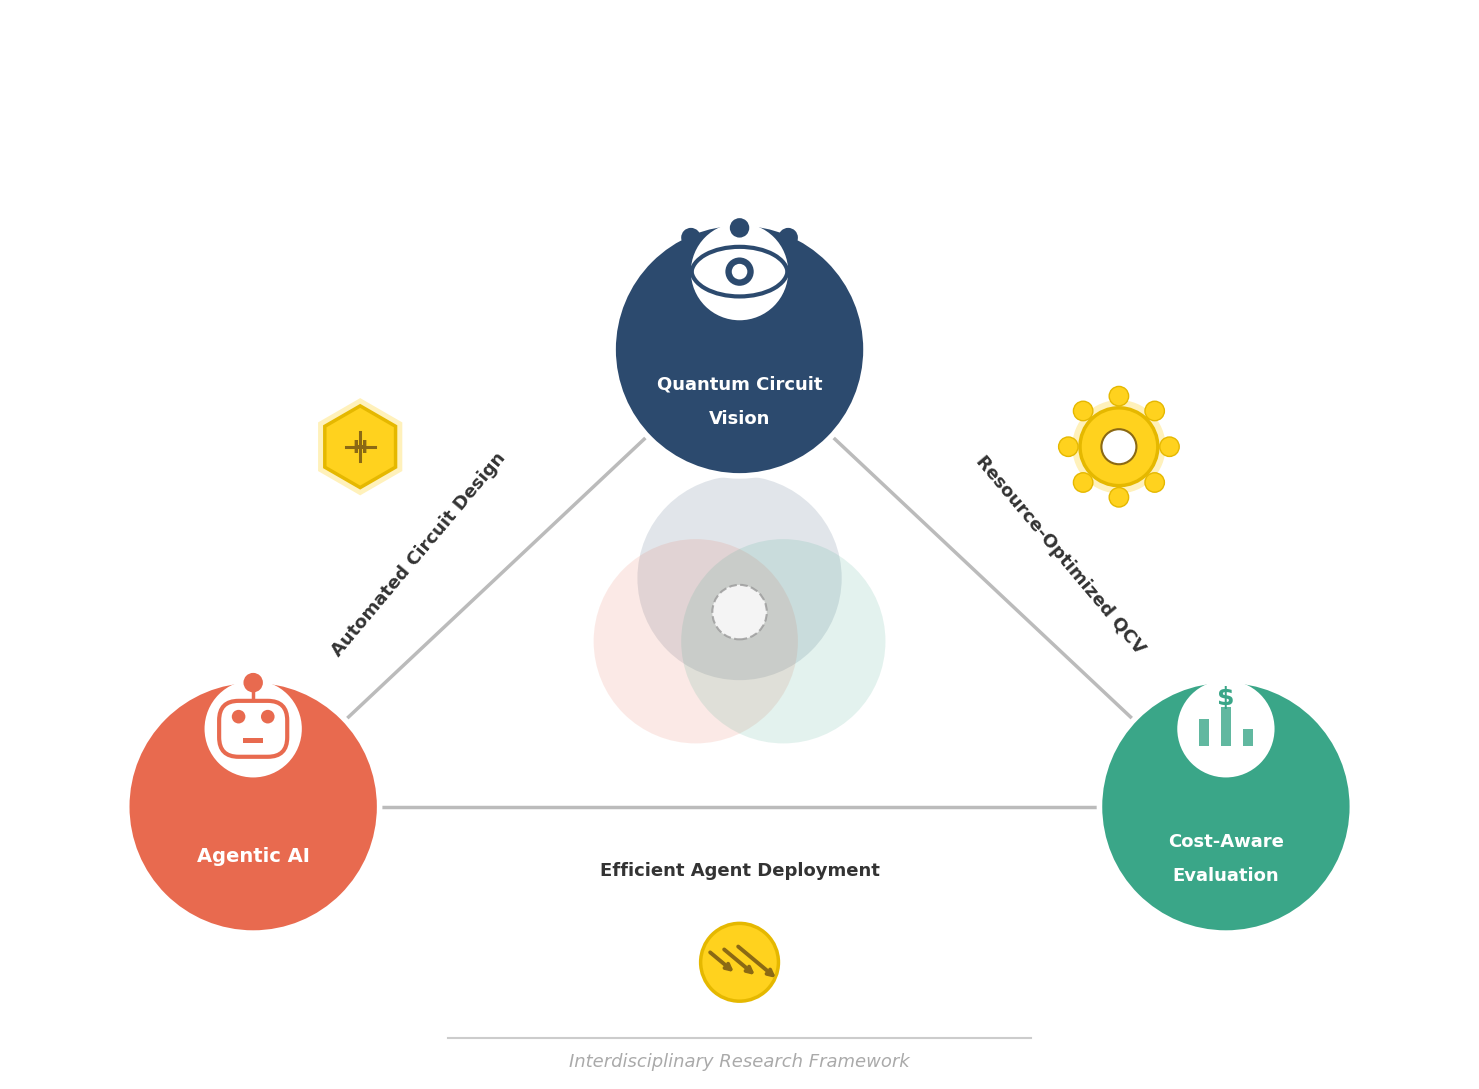

Saved!


In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle, FancyBboxPatch, Arc, RegularPolygon, Wedge, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(15, 11), facecolor='white')
ax.set_xlim(0, 15)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_aspect('equal')

pos = {
    'qcv': (7.5, 7.5),
    'agent': (2.5, 2.8),
    'cost': (12.5, 2.8),
}

colors = {
    'qcv': '#2C4A6E',
    'agent': '#E86A4F',
    'cost': '#3AA688',
}

# Hugging Face yellow for edge icons — warm, recognizable, neutral to all nodes
ICON_COLOR = '#FFD21E'
ICON_TEXT_COLOR = '#8B6914'  # Dark golden text on yellow

node_r = 1.3
icon_r = 0.5
inner_offset = node_r - icon_r  # = 0.8

def circle_edge_point(cx1, cy1, cx2, cy2, r):
    dx = cx2 - cx1
    dy = cy2 - cy1
    dist = np.sqrt(dx**2 + dy**2)
    return cx1 + r * dx/dist, cy1 + r * dy/dist

# ===== CONNECTION LINES =====
qx, qy = pos['qcv']
ax_x, ay = pos['agent']
ex1, ey1 = circle_edge_point(qx, qy, ax_x, ay, node_r)
ex2, ey2 = circle_edge_point(ax_x, ay, qx, qy, node_r)
ax.plot([ex1, ex2], [ey1, ey2], color='#bbbbbb', linewidth=2.5, zorder=1)

cx, cy = pos['cost']
ex3, ey3 = circle_edge_point(ax_x, ay, cx, cy, node_r)
ex4, ey4 = circle_edge_point(cx, cy, ax_x, ay, node_r)
ax.plot([ex3, ex4], [ey3, ey4], color='#bbbbbb', linewidth=2.5, zorder=1)

ex5, ey5 = circle_edge_point(qx, qy, cx, cy, node_r)
ex6, ey6 = circle_edge_point(cx, cy, qx, qy, node_r)
ax.plot([ex5, ex6], [ey5, ey6], color='#bbbbbb', linewidth=2.5, zorder=1)

# ===== EDGE TEXT =====
ax.text(4.2, 5.4, 'Automated Circuit Design', fontsize=13, fontweight='bold',
        ha='center', va='center', color='#333333', rotation=50, zorder=5)
ax.text(7.5, 2.15, 'Efficient Agent Deployment', fontsize=13, fontweight='bold',
        ha='center', va='center', color='#333333', zorder=5)
ax.text(10.8, 5.4, 'Resource-Optimized QCV', fontsize=13, fontweight='bold',
        ha='center', va='center', color='#333333', rotation=-50, zorder=5)

# ===== EDGE ICONS — LARGER, MORE BEAUTIFUL, CLOSER TO TEXT, YELLOW =====

# Left: Quantum gate (H) — larger hexagon with circuit motif, closer to text
lix, liy = 3.6, 6.5
hex_r = 0.42
# Outer glow
glow = RegularPolygon((lix, liy), 6, radius=hex_r+0.08,
                       facecolor=ICON_COLOR, edgecolor='none',
                       zorder=5, alpha=0.3)
ax.add_patch(glow)
hexagon = RegularPolygon((lix, liy), 6, radius=hex_r,
                          facecolor=ICON_COLOR, edgecolor='#E5B800',
                          linewidth=2.5, zorder=6)
ax.add_patch(hexagon)
# Inner circuit motif
ax.plot([lix-0.15, lix+0.15], [liy, liy], color=ICON_TEXT_COLOR, linewidth=2.2, zorder=7)
ax.plot([lix, lix], [liy-0.15, liy+0.15], color=ICON_TEXT_COLOR, linewidth=2.2, zorder=7)
ax.text(lix, liy, 'H', fontsize=13, ha='center', va='center',
        color=ICON_TEXT_COLOR, fontweight='bold', zorder=8)

# Bottom: Cascading arrows — larger, closer to text
bix, biy = 7.5, 1.2
# Background circle
cascade_bg = Circle((bix, biy), 0.4, facecolor=ICON_COLOR,
                     edgecolor='#E5B800', linewidth=2.5, zorder=5)
ax.add_patch(cascade_bg)
# Three arrows in different sizes
for i, (dx, scale) in enumerate([(-0.18, 0.8), (0, 1.0), (0.18, 1.2)]):
    arr_len = 0.18 * scale
    ax.annotate('', xy=(bix + dx + arr_len, biy - 0.15*scale),
                xytext=(bix + dx - arr_len, biy + 0.15*scale),
                arrowprops=dict(arrowstyle='->', color=ICON_TEXT_COLOR, lw=2.8), zorder=6)

# Right: Gear/settings icon — larger, closer to text
rix, riy = 11.4, 6.5
# Outer glow
glow_r = Circle((rix, riy), 0.48, facecolor=ICON_COLOR,
                edgecolor='none', zorder=5, alpha=0.3)
ax.add_patch(glow_r)
# Main circle
outer = Circle((rix, riy), 0.4, facecolor=ICON_COLOR,
               edgecolor='#E5B800', linewidth=2.5, zorder=6)
ax.add_patch(outer)
# Inner white circle
inner_gear = Circle((rix, riy), 0.18, facecolor='white',
                     edgecolor=ICON_TEXT_COLOR, linewidth=1.5, zorder=7)
ax.add_patch(inner_gear)
# Gear teeth — 8 teeth
for angle in np.linspace(0, 2*np.pi, 8, endpoint=False):
    gx = rix + 0.52 * np.cos(angle)
    gy = riy + 0.52 * np.sin(angle)
    tooth = Circle((gx, gy), 0.1, facecolor=ICON_COLOR,
                   edgecolor='#E5B800', linewidth=1, zorder=6)
    ax.add_patch(tooth)

# ===== CENTRAL VENN =====
venn_center = (7.5, 4.8)
venn_r = 1.05
offsets = [(0, 0.35), (-0.45, -0.3), (0.45, -0.3)]
for i, (key, color) in enumerate(colors.items()):
    ox, oy = offsets[i]
    circle = Circle((venn_center[0] + ox, venn_center[1] + oy), venn_r,
                    facecolor=color, alpha=0.14, edgecolor='none', zorder=2)
    ax.add_patch(circle)
inner_fusion = Circle(venn_center, 0.28, facecolor='white', edgecolor='#999999',
                       linewidth=1.5, linestyle='--', alpha=0.8, zorder=3)
ax.add_patch(inner_fusion)

# ===== MAIN NODES =====
def draw_qcv_icon(ax, cx, cy, r, color):
    eye_w = r * 0.9
    eye_h = r * 0.5

    arc_upper = Arc((cx, cy - eye_h*0.08), eye_w*2.2, eye_h*2.2, angle=0,
                     theta1=0, theta2=180, color=color, linewidth=3, zorder=12)
    ax.add_patch(arc_upper)
    arc_lower = Arc((cx, cy + eye_h*0.08), eye_w*2.2, eye_h*2.2, angle=0,
                     theta1=180, theta2=360, color=color, linewidth=3, zorder=12)
    ax.add_patch(arc_lower)

    iris_r = r * 0.32
    iris = Circle((cx, cy), iris_r, facecolor=color, edgecolor='white', linewidth=2, zorder=13)
    ax.add_patch(iris)
    pupil = Circle((cx, cy), iris_r * 0.5, facecolor='white', edgecolor='none', zorder=14)
    ax.add_patch(pupil)

    node_positions = [
        (cx - r, cy + r*0.7),
        (cx + r, cy + r*0.7),
        (cx - r*1.1, cy - r*0.5),
        (cx + r*1.1, cy - r*0.5),
        (cx, cy + r*0.9),
    ]
    for nx, ny in node_positions:
        dot = Circle((nx, ny), 0.1, facecolor=color, edgecolor='none', zorder=11)
        ax.add_patch(dot)

def draw_agent_icon(ax, cx, cy, r, color):
    head_w = r * 1.2
    head_h = r * 0.95
    head = FancyBboxPatch((cx - head_w/2, cy - head_h/2), head_w, head_h,
                           boxstyle="round,pad=0.05,rounding_size=0.2",
                           facecolor='white', edgecolor=color, linewidth=3, zorder=12)
    ax.add_patch(head)

    eye_r = r * 0.14
    left_eye = Circle((cx - r*0.3, cy + r*0.25), eye_r, facecolor=color, edgecolor='none', zorder=13)
    right_eye = Circle((cx + r*0.3, cy + r*0.25), eye_r, facecolor=color, edgecolor='none', zorder=13)
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    mouth = patches.Rectangle((cx - r*0.2, cy - r*0.3), r*0.4, r*0.12,
                       facecolor=color, edgecolor='none', zorder=13)
    ax.add_patch(mouth)

    ax.plot([cx, cx], [cy + head_h/2, cy + r*0.85], color=color, linewidth=2.5, zorder=11)
    ant_dot = Circle((cx, cy + r*0.95), 0.1, facecolor=color, edgecolor='none', zorder=12)
    ax.add_patch(ant_dot)

def draw_cost_icon(ax, cx, cy, r, color):
    bar_w = r * 0.2
    bar_heights = [r*0.55, r*0.8, r*0.35]
    bar_xs = [cx - r*0.45, cx, cx + r*0.45]

    for bx, bh in zip(bar_xs, bar_heights):
        bar = patches.Rectangle((bx - bar_w/2, cy - r*0.35), bar_w, bh,
                         facecolor=color, edgecolor='none', alpha=0.8, zorder=12)
        ax.add_patch(bar)

    ax.text(cx, cy + r*0.65, '$', fontsize=18, fontweight='bold', color=color,
            ha='center', va='center', zorder=13)

for key, (x, y) in pos.items():
    color = colors[key]

    circle = Circle((x, y), node_r, facecolor=color, edgecolor='white', linewidth=4, zorder=10)
    ax.add_patch(circle)

    inner_cy = y + node_r - icon_r
    inner = Circle((x, inner_cy), icon_r, facecolor='white', edgecolor='none', zorder=11)
    ax.add_patch(inner)

    if key == 'qcv':
        draw_qcv_icon(ax, x, inner_cy, icon_r, color)
    elif key == 'agent':
        draw_agent_icon(ax, x, inner_cy, icon_r, color)
    elif key == 'cost':
        draw_cost_icon(ax, x, inner_cy, icon_r, color)

    if key == 'qcv':
        ax.text(x, y - 0.35, 'Quantum Circuit', fontsize=13, fontweight='bold',
                ha='center', va='center', color='white', zorder=15)
        ax.text(x, y - 0.7, 'Vision', fontsize=13, fontweight='bold',
                ha='center', va='center', color='white', zorder=15)
    elif key == 'agent':
        ax.text(x, y - 0.5, 'Agentic AI', fontsize=14, fontweight='bold',
                ha='center', va='center', color='white', zorder=15)
    elif key == 'cost':
        ax.text(x, y - 0.35, 'Cost-Aware', fontsize=13, fontweight='bold',
                ha='center', va='center', color='white', zorder=15)
        ax.text(x, y - 0.7, 'Evaluation', fontsize=13, fontweight='bold',
                ha='center', va='center', color='white', zorder=15)

# ===== HORIZONTAL LINE + SUBTITLE =====
ax.plot([4.5, 10.5], [0.42, 0.42], color='#cccccc', linewidth=1.5, zorder=5)
ax.text(7.5, 0.18, 'Interdisciplinary Research Framework', fontsize=13,
        ha='center', va='center', color='#aaaaaa', style='italic')

plt.tight_layout()
plt.savefig('Interdisciplinary_Framework.png',
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved!")
